# Kompresija slika

## Skup podataka

In [1]:
import numpy as np
from matplotlib import pyplot as plt
from numpy import linalg as LA
import pywt
import cv2
import math

#pip install scikit-image
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim

def plot_comparison(original, reconstructed, method_name):
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    
    axes[0].imshow(original, cmap='gray')
    axes[0].set_title('Original Image')
    axes[0].axis('off') 
    
    # Right subplot: Reconstructed
    axes[1].imshow(reconstructed, cmap='gray')
    axes[1].set_title(f'{method_name}')
    axes[1].axis('off')
    
    plt.tight_layout()
    plt.show()
    
def to_uint8(img):
    #final result clipped to the [0,255] range
    return np.clip(np.round(img), 0, 255).astype(np.uint8)

## Metode

### 1. JPEG-DCT

JPEG (Joint Photographic Experts Group) je standardizovani algoritam za kompresiju slika sa gubitkom.

#### Arhitektura procesa kompresije:
1. Kolor konverzija(RGB ili drugog modela u YCbCr)
2. Diskretna kosinusna transformacija
3. Kvantizacija
4. Cik-Cak skeniranje i Hafmanovo kodiranje(kompresija bez gubitka)

#### 1. Kolor konverzija (RGB u YCbCr)
Ljudsko oko primećuje promene u osvetljenju bolje nego promene u nijansama boja. Zbog toga se RGB prostor prevodi u YCbCr domen pomoću sledeće transformacione matrice:

$$\begin{bmatrix} Y \\ Cb \\ Cr \end{bmatrix} = \begin{bmatrix} 0 & 0.299 & 0.587 & 0.114 \\ 0 & -0.168736 & -0.331264 & 0.5 \\ 0 & 0.5 & -0.418688 & -0.081312 \end{bmatrix} \begin{bmatrix} R \\ G \\ B \end{bmatrix} + \begin{bmatrix} 0 \\ 128 \\ 128 \end{bmatrix}$$

> **Napomena:** Svi naredni koraci izvršavaju se potpuno nezavisno i paralelno nad svakim kanalom ($Y$, $Cb$ i $Cr$).

#### 2. Dvodimenzionalna DCT-II Transformacija
Slika se deli na nezavisne blokove dimenzija $8 \times 8$ piksela. Nad svakim, prethodno centriranim blokom (oduzimanjem vrednosti 128), primenjuje se dvodimenzionalna diskretna kosinusna transformacija koja prostorne intenzitete piksela prevodi u koeficijente prostornih frekvencija:

$$DCT(u, v) = \frac{1}{4} C(u) C(v) \sum_{x=0}^{7} \sum_{y=0}^{7} f(x, y) \cos\left[\frac{(2x + 1)u\pi}{16}\right] \cos\left[\frac{(2y + 1)v\pi}{16}\right]$$

Gde su $f(x, y)$ vrednosti prostornih piksela unutar bloka, a $C(u)$ i $C(v)$ definisani kao:

$$C(\xi) = \begin{cases} \frac{1}{\sqrt{2}}, & \text{za } \xi = 0 \\ 1, & \text{za } \xi > 0 \end{cases}$$

Koeficijent u gornjem levom uglu ($DCT(0,0)$) predstavlja **DC komponentu** (srednju vrednost osvetljenja bloka), dok ostala 63 elementa predstavljaju **AC komponente** viših frekvencija.

#### 3. Kvantizacija 
Kompresija sa gubitkom se zapravo odigrava u koraku kvantizacije. Frekvencijski koeficijenti svakog bloka unutar svakog kanala se dele elementima matrice kvantizacije $Q$ i zaokružuju na cele brojeve. Za kanal osvetljenosti ($Y$) koristi se matrica $Q_Y$, dok se za kanale boja ($Cb, Cr$) koristi agresivnija hrominantna matrica $Q_C$.

$$C(u, v) = \text{round}\left(\frac{DCT(u, v)}{Q(u, v)}\right)$$

Ovaj korak pretvara većinu AC koeficijenata visokih frekvencija (u donjem desnom delu matrice) u nule, čime se eliminišu vizuelno manje bitni detalji i postiže glavni faktor kompresije.

#### 4. Entropijsko kodiranje
Nakon kvantizacije, nad preostalim koeficijentima se vrši finalna kompresija bez gubitka (entropijsko kodiranje kroz RLE i Hafmanov algoritam). Za potrebe ovog projekta, gde je fokus na upoređivanju različitih tehnika kompresije sa gubitkom u frekvencijskom domenu, nećemo dublje ulaziti u detalje samog entropijskog kodiranja.

#### Rekonstrukcija slike (Inverzni proces)
Proces dekompresije počinje dekvantizacijom gde se rekonstruišu približni frekvencijski koeficijenti: $R(u, v) = C(u, v) \times Q(u, v)$. Nakon toga, primenjuje se inverzna diskretna kosinusna transformacija (2D IDCT) kako bi se podaci vratili u prostorni domen piksela, uz poništavanje početnog centriranja:

$$f'(x, y) = \text{IDCT}(R(u, v)) + 128$$

#### Primena

JPEG zasnovan na DCT-u je postao industrijski standard zahvaljujući svojoj računskoj jednostavnosti, izuzetnoj hardverskoj podršci i zadovoljavajućim performansama pri umerenim stepenima kompresije.

Međutim, algoritam pati od jednog fundamentalnog nedostatka:

* **Problem blok-artefakata (Blocking Artifacts):** Pošto se slika striktno deli na izolovane $8 \times 8$ blokove, korelacija i kontinuitet signala preko granica tih blokova bivaju potpuno ignorisani. Pri višim stepenima kompresije granice blokova postaju oštre i vidljive ljudskom oku.

Pokušaji rešavanja ovog problema, poput Lapped Orthogonal Transforms (LOT) koji koriste glatko preklapanje blokova, drastično povećavaju računarsku kompleksnost, što u praksi nije opravdalo masovnu zamenu standardnog DCT-a. To otvara prostor za **talasiće (DWT)** koji ne dele početnu sliku na blokove.


In [37]:
def jpeg_compression(img,Q):
    img= np.float32(img)-128
    
    block_size=8
    h,w= img.shape
    nbh= math.ceil(h/block_size)
    nbw= math.ceil(w/block_size)
    H,W= nbh*block_size, nbw*block_size
    padded_img= np.zeros((H,W), dtype= np.float32)
    padded_img[0:h,0:w]= img
    
   # print(f'Before padding:{img.shape}')
   # print(f'After padding:{padded_img.shape}')
    
    #forward dct
    dct_coef= np.zeros((H,W),dtype=np.float32)
    for i in range(nbh):
        h1,h2= i*block_size, (i+1)*block_size
        for j in range(nbw):
            w1,w2= j*block_size, (j+1)*block_size
            block= padded_img[h1:h2,w1:w2]
            dct_coef[h1:h2,w1:w2]= cv2.dct(block)
    
    
    #quantization
    quantized_matrix= np.zeros((H,W),dtype=np.float32)
    for i in range(nbh):
        h1,h2= i*block_size, (i+1)* block_size
        for j in range(nbw):
            w1,w2= j* block_size,(j+1)*block_size
            quantized_matrix[h1:h2,w1:w2]= np.around(dct_coef[h1:h2,w1:w2]/Q)

  
    return quantized_matrix, (h,w)

def jpeg_decompress(quantized_img,Q, org_shape):
    block_size=8
    H,W= quantized_img.shape
    nbh,nbw= H//block_size,W//block_size
    
    #dequantization
    dequantized_coef= np.zeros((H, W), dtype=np.float32)
    for i in range(nbh):
        h1,h2= i*block_size, (i+1)* block_size
        for j in range(nbw):
            w1,w2= j* block_size,(j+1)*block_size
            dequantized_coef[h1:h2,w1:w2]= quantized_img[h1:h2,w1:w2]*Q
                
    
    #inverse_dct 
    reconstruct_img= np.zeros((H,W), dtype=np.float32)
    for i in range(nbh):
        h1,h2= i*block_size, (i+1)* block_size
        for j in range(nbw):
            w1,w2= j* block_size,(j+1)*block_size
            block=dequantized_coef[h1:h2,w1:w2]
            reconstruct_img[h1:h2,w1:w2]= cv2.idct(block)+128.0
                
    h,w= org_shape
    reconstruct_img= reconstruct_img[0:h,0:w]
    #print(reconstruct_img.dtype)
    return reconstruct_img

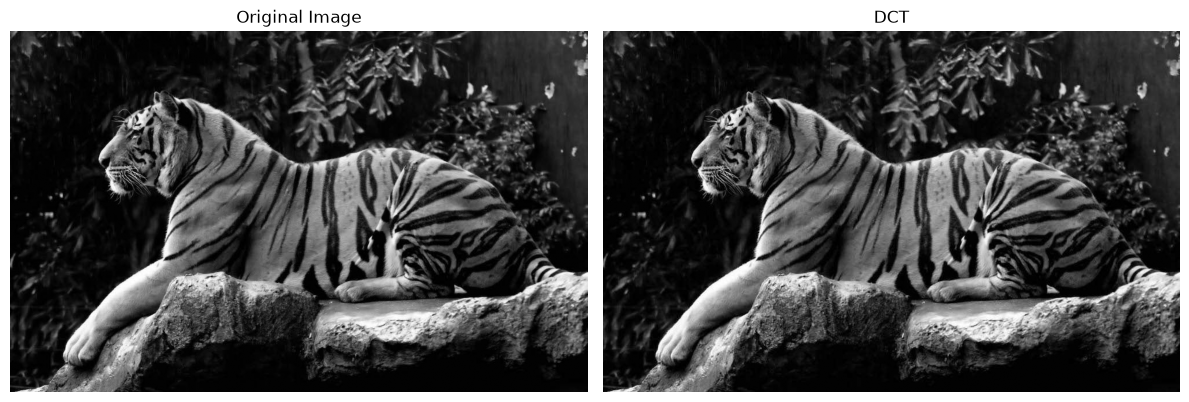

In [38]:
# define quantization tables
#for now only using first table
QTY = np.array([[16, 11, 10, 16, 24, 40, 51, 61],  # luminance quantization table
                [12, 12, 14, 19, 26, 48, 60, 55],
                [14, 13, 16, 24, 40, 57, 69, 56],
                [14, 17, 22, 29, 51, 87, 80, 62],
                [18, 22, 37, 56, 68, 109, 103, 77],
                [24, 35, 55, 64, 81, 104, 113, 92],
                [49, 64, 78, 87, 103, 121, 120, 101],
                [72, 92, 95, 98, 112, 100, 103, 99]])

QTC = np.array([[17, 18, 24, 47, 99, 99, 99, 99],  # chrominance quantization table
                [18, 21, 26, 66, 99, 99, 99, 99],
                [24, 26, 56, 99, 99, 99, 99, 99],
                [47, 66, 99, 99, 99, 99, 99, 99],
                [99, 99, 99, 99, 99, 99, 99, 99],
                [99, 99, 99, 99, 99, 99, 99, 99],
                [99, 99, 99, 99, 99, 99, 99, 99],
                [99, 99, 99, 99, 99, 99, 99, 99]])


#example
img= cv2.imread('data/tiger.jpg',cv2.IMREAD_GRAYSCALE)
q_img,img_shape=jpeg_compression(img,QTY)
rec_img=to_uint8(jpeg_decompress(q_img,QTY,img_shape))

#print(psnr(img,rec_img))
#print(ssim(img,rec_img))
#print(img.shape, rec_img.shape)
plot_comparison(img,rec_img,"DCT")

### 2. SVD

#### Teorijske osnove

Svaka realna matrica $A$ dimenzija $m \times n$ može se razložiti *singularnom dekompozicijom* (Singular Value Decomposition):

$$A = U \Sigma V^T$$

gde su:
- $U$ ($m \times m$) i $V$ ($n \times n$) ortogonalne matrice čije kolone čine *leve* ($U_i$) i *desne* ($V_i$) *singularne vektore*,
- $\Sigma$ ($m \times n$) dijagonalna matrica nenegativnih *singularnih vrednosti* poređanih opadajuće: $\sigma_1 \ge \sigma_2 \ge \dots \ge \sigma_R > 0$, gde je $R$ rang matrice.

Posmatrajući sliku u nijansama sive kao matricu, dekompozicija se može zapisati kao zbir matrica ranga 1:

$$A = \sum_{i=1}^{R} \sigma_i \, U_i V_i^T$$

Zadržavanjem samo prvih $r < R$ članova dobija se **nisko-rang aproksimacija**:

$$A_r = \sum_{i=1}^{r} \sigma_i \, U_i V_i^T = U_r \Sigma_r V_r^T$$

gde su $U_r$, $\Sigma_r$ i $V_r$ matrice dobijene izvlačenjem prvih $r$ kolona, odnosno redova, odgovarajućih matrica.

Matrica $A_r$ je najbolja moguća aproksimacija ranga $r$ u smislu najmanje greške u Frobenijusovoj normi $\lVert A - A_r \rVert$.

Kompresija proizlazi iz toga što se umesto $m \cdot n$ vrednosti čuva samo $r(m + n + 1)$ vrednosti, što dovodi do uštede kada je $r \ll \min(m, n)$.

#### Primena

SVD je **globalna** metoda: za razliku od JPEG-a ne deli sliku na blokove, pa ne stvara blok-artifakte, a greška se ispoljava kao blago zamućenje i gubitak sitnih detalja.

* **Parametar kompresije:** rang $r$ je jedini parametar kojim se direktno reguliše odnos kvalitet/kompresija. Manje $r$ daje jaču kompresiju i nižu vernost.
* **Slike u boji** obrađuju se primenom postupka nezavisno po svakom kanalu.
* **Nedostaci:** samo računanje SVD-a je računski zahtevno sa složenošću $O(\min(m,n)\,mn)$ i velikim konstantnim faktorom.

Funkcija `svd_compression` koristi `numpy.linalg.svd` i rekonstruiše sliku iz prvih $r$ singularnih vrednosti i odgovarajućih vektora.

In [2]:
def svd_compression(image, r):
    U, S, VT = LA.svd(image)
    Ur = U[:, :r]
    Sr = np.diag(S[:r])
    VTr = VT[:r, :]
    
    reconstructed_img = np.dot(np.dot(Ur, Sr), VTr)
    #print(reconstructed_img.min()) - min and max out of [0,255]
    return reconstructed_img

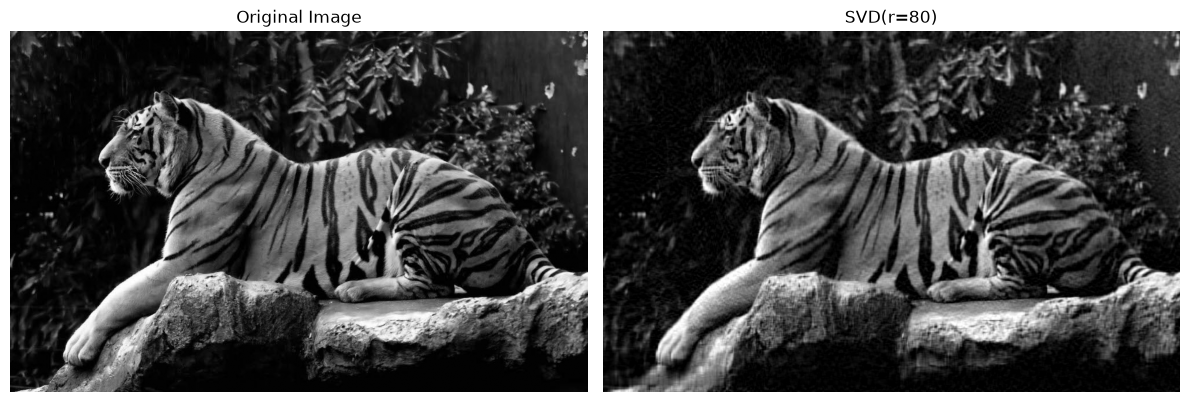

In [42]:
img = cv2.imread("data/tiger.jpg", cv2.IMREAD_GRAYSCALE)
r=80
comp_img = to_uint8(svd_compression(img,r))

plot_comparison(img, comp_img, f"SVD(r={r})")

###  3. DWT

#### Teorijske osnove

Sistem trigonometrijskih funkcija, na kome počiva DCT, ne dozvoljava lokalizaciju frekvencija: ako je neka frekvencija prisutna u signalu, tretira se kao prisutna tokom celog njegovog trajanja, pa je takav sistem nepogodan za aproksimaciju neglatkih signala (ivice, nagle promene). *Talasići* su konstruisani kao alternativa pogodna za ovakve situacije.

Ključna ideja je da se na konačnom intervalu definiše *osnovni talasić* $\psi$, što je funkcija koja ne mora biti glatka ni neprekidna. Od nje se translacijama i skaliranjem generiše ortonormirani sistem kojim se proizvoljno dobro mogu aproksimirati funkcije prostora $L^2(\mathbb{R})$:

$$\psi_{ij}(x) = 2^{i/2}\, \psi(2^i x - j), \qquad i, j \in \mathbb{Z}$$

Parametar $j$ određuje translaciju, a parametar $i$ skaliranje (porastom $i$ raste amplituda, a sužava se oblast u kojoj je talasić različit od nule). Klasičan primer osnovnog talasića je *Harova funkcija*:

$$\psi(x) = \begin{cases} 1, & x \in [0, \frac{1}{2}) \\ -1, & x \in [\frac{1}{2}, 1) \\ 0, & x \notin [0, 1) \end{cases}$$

Razlaganje signala po ovakvoj bazi naziva se *talasasta transformacija*, a u praksi je najvažnija *diskretna talasasta transformacija* (DWT). Analogno brzoj Furijeovoj transformaciji, postoji i algoritam za *brzu talasastu transformaciju* koji radi u vremenu $\Theta(n)$.

Kompresija sa gubitkom postiže se postavljanjem praga (engl. thresholding). Koeficijenti čija je apsolutna vrednost manja od zadatog praga postavljaju se na nulu, pa se slika predstavlja malim brojem značajnih koeficijenata, a rekonstruiše inverznom transformacijom.

#### Primena

Najpoznatija primena talasića u kompresiji slika je standard *JPEG 2000*, koji koristi talasastu transformaciju umesto diskretne kosinusne transformacije. U poređenju sa običnim JPEG-om, ovakav pristup daje viši stepen kompresije, oštrije ivice i izbegava pojavu blokova.

* **Parametri:** izbor osnovnog talasića (npr. Daubechies `db2`), broj nivoa dekompozicije i prag.
* **Implementacija** koristi biblioteku `pywt`: `wavedec2` za dekompoziciju i `waverecn` za rekonstrukciju, dok se pragovanje izvodi nad nizom svih koeficijenata. Funkcije `dwt_compression` i `dwt_decompression` date su u nastavku i ponovo se koriste u hibridnom metodu.

In [4]:
def dwt_compression(img, wavelet, mode, level, compression_level):
    #compression_level = udeo koeficijenata koji se zadrzava (npr. 0.05 -> 5% najvecih)
    coef = pywt.wavedec2(img, wavelet, mode, level)
    arr, slices = pywt.coeffs_to_array(coef)

    #prag ispod koga pada (1 - compression_level) najmanjih koeficijenata po apsolutnoj vrednosti
    thresh_index = min(int(arr.size * (1 - compression_level)), arr.size - 1)
    thresh = np.sort(np.abs(arr.ravel()))[thresh_index]
    arr_compr = arr * (np.abs(arr) > thresh)

    return arr_compr, slices


def dwt_decompression(img_comp, slices, wavelet, mode, level, img_shape):
    coef = pywt.array_to_coeffs(img_comp, slices, output_format="wavedecn")
    reconstructed_img = pywt.waverecn(coef, wavelet=wavelet, mode=mode)

    #odsecanje na originalne dimenzije (rekonstrukcija moze biti malo veca zbog dopune)
    h, w = img_shape
    return reconstructed_img[0:h, 0:w]

Zadrzano koeficijenata: 5.00%
PSNR: 30.95 dB
SSIM: 0.8729


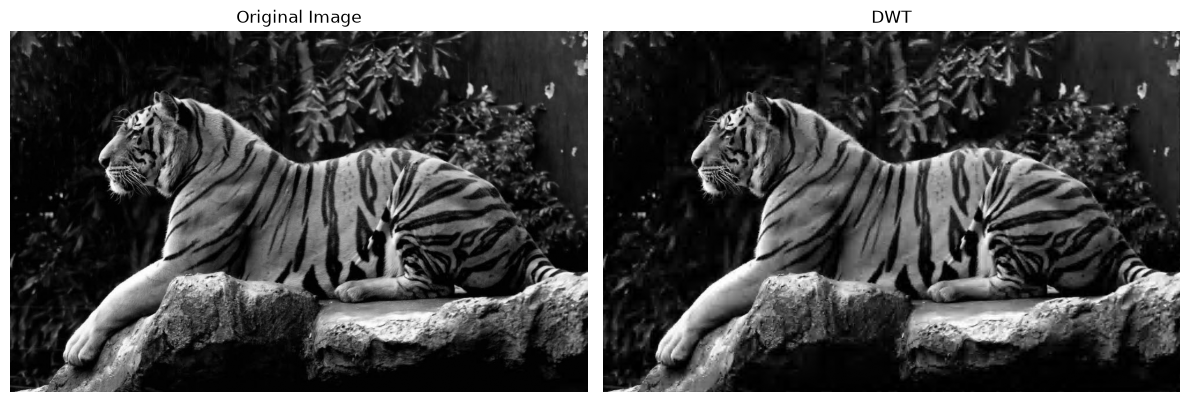

In [43]:
wavelet = "db2"
mode = "periodization"
level = 5
compression_level = 0.05  #zadrzava se 5% najvecih koeficijenata

comp_img, slices = dwt_compression(img, wavelet, mode, level, compression_level)
rec_img = to_uint8(dwt_decompression(comp_img, slices, wavelet, mode, level, img.shape))

print(f"Zadrzano koeficijenata: {np.count_nonzero(comp_img) / comp_img.size:.2%}")
print(f"PSNR: {psnr(img, rec_img):.2f} dB")
print(f"SSIM: {ssim(img, rec_img):.4f}")

plot_comparison(img, rec_img, "DWT")

U potrazi za prevazilaženjem ograničenja pojedinačnih metoda razvijeni su različiti hibridni modeli koji kombinuju prednosti rada u različitim domenima (poput DCT, DWT i SVD transformacija). Primeri iz literature uključuju kompleksne trostruke hibride poput **DWT-SVD-DCT** sistema, koji se uspešno koriste za specifične satelitske snimke, kao i kombinacije SVD-a sa drugim tehnikama (poput WDR-a) radi optimizacije srednje kvadratne greške (MSE).

Dok je u ranijim istraživanjima viši stepen kompresije gotovo uvek postizan na štetu kvaliteta slike (odnosno uz pad PSNR vrednosti), fokus ovog hibridnog modela je optimizacija oba parametra paralelno, odnosno postizanje boljeg kompresionog odnosa bez ugrožavanja finalnog kvaliteta rekonstruisane slike.

### 4. Hibrid SVD i DWT

 SVD i DWT metode kompresuju sliku po dva fundamentalno različita principa: SVD pronalazi globalnu nisko-rang aproksimaciju matrice slike (zadržava samo r najznačajnijih singularnih vrednosti), dok DWT razlaže sliku na frekvencijske komponente i odbacuje koeficijente ispod određenog praga. Hibridni pristup kombinuje ova dva mehanizma u ***sekvencijalni pipline***, gde se izlaz jedne metode prosleđuje kao ulaz drugoj.

#### Arhitektura metoda kompresije:
 
1. ***SVD korak*** - originalna slika $A$ se faktorizuje kao $A = U\Sigma V^T$, a zadržava se samo prvih $r$ singularnih vrednosti i odgovarajućih vektora, čime se dobija nisko-rang aproksimacija $A_r = U_r \Sigma_r V_r^T$. 
2. **DWT korak** - rezultujuća SVD-aproksimirana slika $A_r$ se dalje kompresuje primenom  DWT-a.

U originalnom radu, hibridni model je testiran sa rangom ($r = 20, 30, 40, 50$) uz fiksne DWT parametre - ‘db2’ (Daubechies2) talasiće i pragom od 80%, nad pet test slika. Glavni nalaz je da hibridni pristup, za isti rang $r$, daje **veći PSNR** (bolji kvalitet) nego primena SVD-a samostalno.




In [44]:
def svd_dwt_compression(img,rank_svd=50,level_dwt=5,mode_dwt='periodization',wavelet='db2',compression_level=0.8):
    img_svd= svd_compression(img,rank_svd)
    
    comp_img, slices=dwt_compression(img_svd, wavelet, mode_dwt, level_dwt, compression_level)
    
    return comp_img,slices

def svd_dwt_decompression(comp_img,slices, img_shape, level_dwt=5, mode_dwt='periodization',wavelet='db2'):
    return dwt_decompression(comp_img,slices, wavelet, mode_dwt, level_dwt, img_shape)


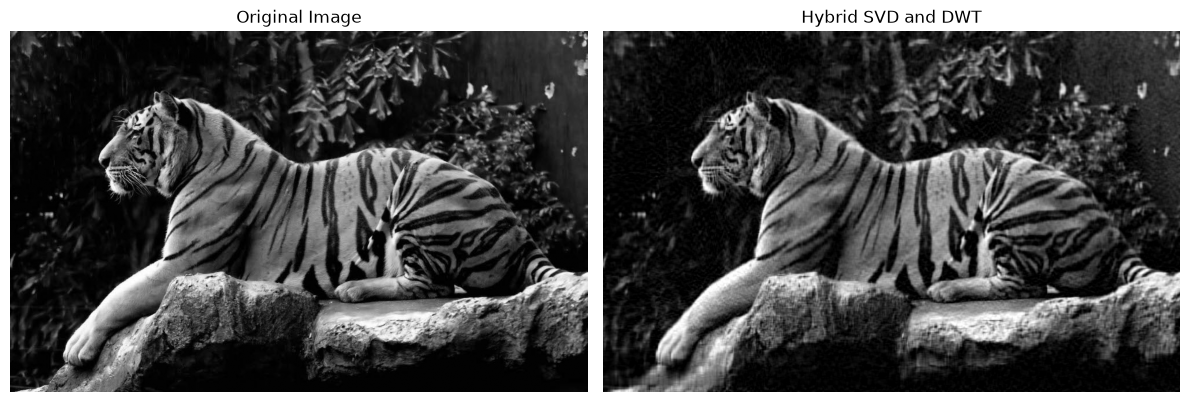

In [45]:
#Hybrid example with r(svd)=80, and compression_level(dwt)=0.8
comp_img,slices= svd_dwt_compression(img,rank_svd=80)
rec_img= to_uint8(svd_dwt_decompression(comp_img,slices,img.shape))
plot_comparison(img, rec_img,"Hybrid SVD and DWT")

## Poredjenje modela

#### Metrike
Kvalitet različitih metoda za kompresiju slika evaluiraju se često kroz dva aspekta **efikasnost kompresije** (ušteda prostora) i **kvalitet rekonstruisane slike**. 

Da bismo uporedili kvalitet kompresije, merimo odstupanje i vernost rekonstruisanog fajla u odnosu na original pomoću opšte formule:

$$N_{\text{quality}} = \text{Quality\_metric}(I, I^*)$$

Neke od standardnih metrika za procenu kvaliteta slike su
#### 1. MSE (Mean squared error)
MSE meri prosečnu kvadratnu razliku između intenziteta piksela originalne i rekonstruisane slike. $M \times N$:

$$\text{MSE} = \frac{1}{M \times N} \sum_{i=0}^{M-1} \sum_{j=0}^{N-1} [I(i,j) - I^*(i,j)]^2$$

#### 2. PSNR (Peak signal to noise ratio)

$$\text{PSNR} = 10 \cdot \log_{10} \left( \frac{R^2}{\text{MSE}} \right)$$

Gde parametar $R$ predstavlja maksimalnu vrednost u opsegu tipu podataka ulazne slike:
* Ako je slika u formatu sa pokretnim zarezom dvostruke tačnosti (`double-precision`), $R = 1$.
* Ako je slika standardni 8-bitni neoznačeni ceo broj (`8-bit unsigned integer / uint8`), vrednost je **$R = 255$**.

#### 3. SSIM (Structural similarity index)
Pošto MSE i PSNR računaju isključivo numeričku grešku na nivou pojedinačnih piksela, oni ne prepoznaju ljudski doživljaj kvaliteta. Strukturna sličnost (SSIM) rešava ovaj nedostatak tako što poredi slike posmatrajući tri komponente: promenu osvetljenja (luminansa), kontrast i strukturnu korelaciju (teksturu):

$$\text{SSIM}(x,y) = \frac{(2\mu_x\mu_y + c_1)(2\sigma_{xy} + c_2)}{(\mu_x^2 + \mu_y^2 + c_1)(\sigma_x^2 + \sigma_y^2 + c_2)}$$

Gde su $x$ i $y$ slike koje se porede, $\mu_x$ i $\mu_y$ prosečne vrednosti slika, $\sigma_x^2$ i $\sigma_y^2$ varijanse slika, a $\sigma_{xy}$ kovarijansa koja meri strukturnu sličnost ivica i tekstura. Konstante $c_1 = (k_1 L)^2$ i $c_2 = (k_2 L)^2$ stabilizuju količnik kada su imenioci bliski nuli, gde je $L$ dinamički opseg piksela (za `uint8` slike $L = 255$), a standardne vrednosti su $k_1 = 0.01$ i $k_2 = 0.03$.

U praksi se SSIM ne računa nad celom slikom odjednom, već lokalno, klizećim prozorom (podrazumevano $7 \times 7$), a konačna vrednost je prosek indeksa po svim prozorima čime metrika prati lokalnu strukturu slike, slično ljudskoj percepciji.

Vrednost SSIM indeksa kreće se u opsegu $[-1, 1]$, gde vrednost $1$ označava savršenu strukturnu i vizuelnu identifikaciju sa originalom.

In [20]:
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim

In [46]:
#x-osa
#stepen kompresije original/sacuvano ---> kako raste veci nivo kompresije 
#      original/original=1 
#using quantized matrix from dct_compression
def compression_factor_dct(quantized):
    original = quantized.size
    kept = np.count_nonzero(quantized)
    return original / kept

#using shape 
def compression_factor_svd(img_shape, r):
    m, n = img_shape
    original = m * n
    kept = r *(m + n + 1)   # U_r: m*r, V_r: r*n, S_r: r 
    return original / kept

def compression_factor_dwt(arr_compr):
    original = arr_compr.size      
    kept = np.count_nonzero(arr_compr)
    return original/kept

#kod hibrida se skladisti isto sto i kod DWT-a (retki koeficijenti nakon pragovanja);
#SVD korak je samo pretprocesiranje ulaza i ne menja kolicinu sacuvanih podataka
def compression_factor_hybrid(arr_compr):
    return compression_factor_dwt(arr_compr)


def calculate_svd(img,ranks):
    axes= [] # elements tuple=(compression_factor,psnr,ssim)
    for r in ranks:
        rec= to_uint8(svd_compression(img,r))
        x= compression_factor_svd(img.shape,r)
        y1= psnr(img,rec)
        y2= ssim(img,rec)
        axes.append((x,y1,y2))
    return axes

def calculate_dwt(img, comp_rates, wavelet="db2", mode="periodization", level=5):
    axes= []
    for rate in comp_rates:
        comp, slices= dwt_compression(img,wavelet,mode,level,rate)
        rec= to_uint8(dwt_decompression(comp,slices,wavelet,mode,level,img.shape))
        x= compression_factor_dwt(comp)
        y1= psnr(img,rec)
        y2= ssim(img,rec)
        axes.append((x,y1,y2))
    return axes
                      
def calculate_dct(img,Q,scalars):
    axes= []
    for s in scalars:
        comp, img_shape=jpeg_compression(img,Q*s)
        rec=to_uint8(jpeg_decompress(comp,Q*s,img_shape))
        x= compression_factor_dct(comp)
        y1= psnr(img,rec)
        y2= ssim(img,rec)
        axes.append((x,y1,y2))
    return axes

#petlja ide po DWT udelima: rang SVD-a ogranicava maksimalni kvalitet,
#a stepen kompresije odredjuje iskljucivo DWT pragovanje
def calculate_hybrid(img, comp_rates, rank_svd=100, wavelet="db2", mode="periodization", level=5):
    axes= []
    for rate in comp_rates:
        comp, slices= svd_dwt_compression(img, rank_svd=rank_svd, level_dwt=level,
                                          mode_dwt=mode, wavelet=wavelet, compression_level=rate)
        rec= to_uint8(svd_dwt_decompression(comp, slices, img.shape, level_dwt=level,
                                            mode_dwt=mode, wavelet=wavelet))
        x= compression_factor_hybrid(comp)
        y1= psnr(img,rec)
        y2= ssim(img,rec)
        axes.append((x,y1,y2))
    return axes

In [47]:
ranks_svd = [10, 20, 30, 50, 80, 100]
dwt_rates = [0.5, 0.2, 0.1, 0.05, 0.01]   #udeo zadrzanih koeficijenata
dct_scalars = [0.2, 0.5, 1.0, 1.5, 2.0, 5.0, 10.0]  #mnozioci kvantizacione tabele
hybrid_rates = [0.5, 0.2, 0.1, 0.05, 0.01]
hybrid_ranks=[50, 80, 100]                     

print("Računam SVD...")
data_svd = calculate_svd(img, ranks_svd)

print("Računam DWT...")
data_dwt = calculate_dwt(img, dwt_rates, level=5)

print("Računam JPEG-DCT...")
data_dct = calculate_dct(img, QTY, dct_scalars)

print("Računam hibrid SVD+DWT...")
data_hybrid = calculate_hybrid(img, hybrid_rates, rank_svd=hybrid_rank)

Računam SVD...
Računam DWT...
Računam JPEG-DCT...
Računam hibrid SVD+DWT...


### Poređenje

Metode postaju uporedive tek kada se prikažu u istom koordinatnom sistemu: na $x$-osi je **faktor kompresije** (koliko puta manje vrednosti čuvamo u odnosu na original), a na $y$-osi kvalitet rekonstrukcije (**PSNR**, odnosno **SSIM**). Za svaku metodu variramo njen parametar kompresije (rang $r$ za SVD, udeo zadržanih koeficijenata za DWT i hibrid, množilac kvantizacione tabele za JPEG-DCT) i tako dobijamo *rate-distortion* krive.

In [49]:
method_style = {
    "SVD":      {"color": "#2a78d6", "marker": "o"},
    "DWT":      {"color": "#1baf7a", "marker": "s"},
    "JPEG-DCT": {"color": "#eda100", "marker": "^"},
}
hybrid_colors = ["#7fbf7f", "#2e8b2e", "#0b4d0b"]   # svetlije -> tamnije zelena po rangu


def plot_rate_distortion(all_data, title=None):
    fig, (ax_psnr, ax_ssim) = plt.subplots(1, 2, figsize=(14, 5))

    h_idx = 0
    for name, data in all_data.items():
        cf, vals_psnr, vals_ssim = zip(*sorted(data))
        if name in method_style:
            st = method_style[name]
        else:   # hibridne krive
            st = {"color": hybrid_colors[h_idx % len(hybrid_colors)], "marker": "D"}
            h_idx += 1

        # PSNR=inf (identicna rekonstrukcija) se preskace na PSNR grafiku
        pts = [(x, y) for x, y in zip(cf, vals_psnr) if np.isfinite(y)]
        if pts:
            xs, ys = zip(*pts)
            ax_psnr.plot(xs, ys, color=st["color"], marker=st["marker"],
                         linewidth=2, markersize=6, label=name)
        ax_ssim.plot(cf, vals_ssim, color=st["color"], marker=st["marker"],
                     linewidth=2, markersize=6, label=name)

    for ax, ylabel in [(ax_psnr, "PSNR [dB]"), (ax_ssim, "SSIM")]:
        ax.set_xscale("log")
        ax.set_xticks([2, 5, 10, 20, 50, 100])
        ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda v, _: f"{v:g}x"))
        ax.xaxis.set_minor_formatter(ticker.NullFormatter())
        ax.set_xlabel("Faktor kompresije")
        ax.set_ylabel(ylabel)
        ax.grid(True, color="#e1e0d9", linewidth=0.8)
        ax.set_axisbelow(True)
        for spine in ("top", "right"):
            ax.spines[spine].set_visible(False)
        ax.legend(frameon=False, fontsize=9)

    fig.suptitle(title or "Odnos stepena kompresije i kvaliteta rekonstrukcije", fontsize=13)
    plt.tight_layout()
    plt.show()


def compare_methods(img,
                    ranks_svd=[10, 20, 30, 50, 80, 100],
                    dwt_rates=[0.5, 0.2, 0.1, 0.05, 0.01],
                    dct_scalars=[0.2, 0.5, 1.0, 1.5, 2.0, 5.0, 10.0],
                    hybrid_rates=[0.5, 0.2, 0.1, 0.05, 0.01],
                    hybrid_ranks=[50, 80, 100],
                    title=None):


    all_data = {
        "SVD":      calculate_svd(img, ranks_svd),
        "DWT":      calculate_dwt(img, dwt_rates),
        "JPEG-DCT": calculate_dct(img, QTY, dct_scalars),
    }
    #familija hibridnih krivih: jedna kriva po rangu, duz krive varira DWT udeo
    for r in hybrid_ranks:
        all_data[f"SVD+DWT (r={r})"] = calculate_hybrid(img, hybrid_rates, rank_svd=r)

    plot_rate_distortion(all_data, title=title)
    return all_data

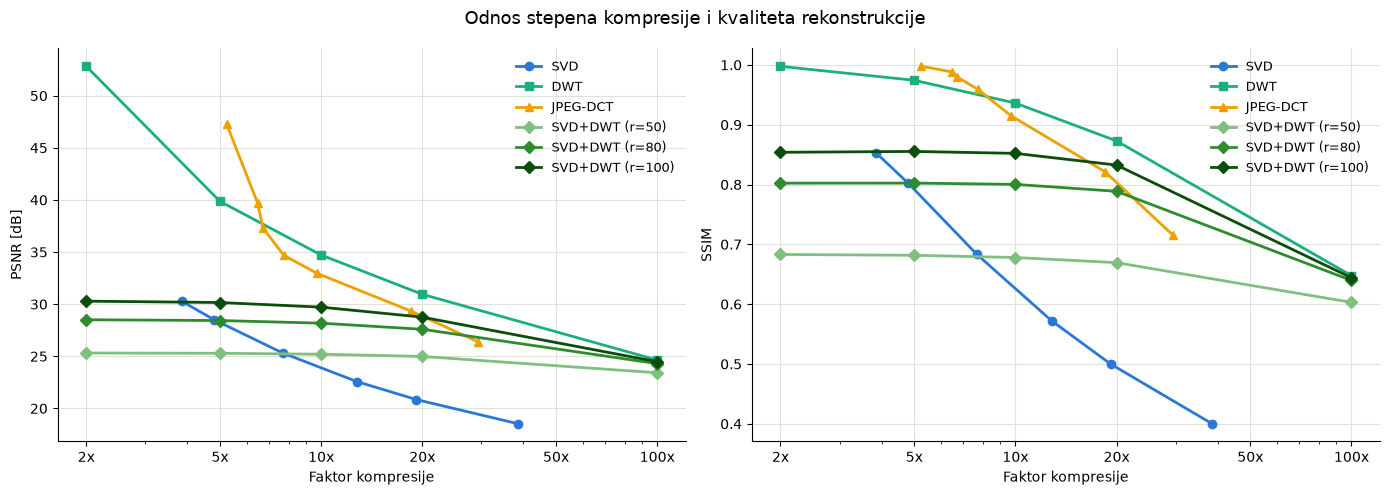

In [52]:
info=compare_methods(img)

Zapažanja sa grafika:

* **DWT** ima najbolji odnos kvaliteta i kompresije na celom opsegu: pri faktoru $20\times$ zadržava oko 31 dB PSNR i SSIM 0.87.
* **JPEG-DCT** ga prati na umerenim stepenima kompresije (oko 29 dB pri $\sim 20\times$), ali kvalitet brže opada zbog blok-artefakata.
* **SVD** je ubedljivo najslabiji po sačuvanom bitu: već pri $\sim 19\times$ (rang 20) pada na 20.9 dB.
* Kriva **hibrida** (rang 100) je gotovo ravna do $\sim 10\times$: kvalitet je odozgo ograničen SVD korakom ($\approx 30.3$ dB), a DWT pragovanje do tog stepena kompresije ne unosi primetnu dodatnu grešku. Pri istom faktoru kompresije hibrid je znatno bolji od čistog SVD-a (oko $+8$ dB pri $20\times$), ali ostaje ispod čistog DWT-a jer SVD korak pre pragovanja samo gubi informacije.

#### Vizuelno poredjenje pri istom faktoru kompresije

Brojevi dobijaju smisao tek uz slike: parametri svake metode izabrani su tako da faktor kompresije bude približno $20\times$, pa je jedina razlika među prikazima način na koji metoda „troši" isti budžet podataka.

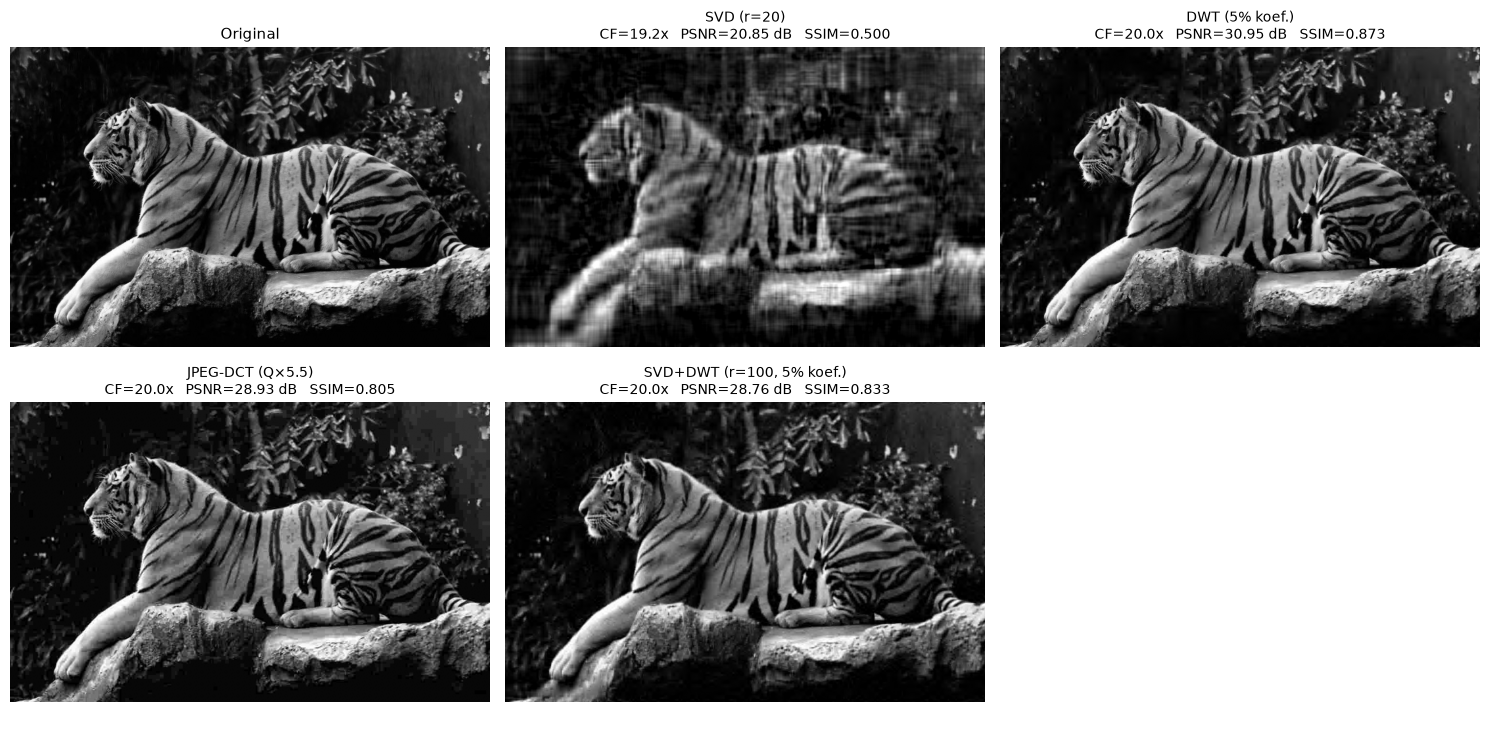

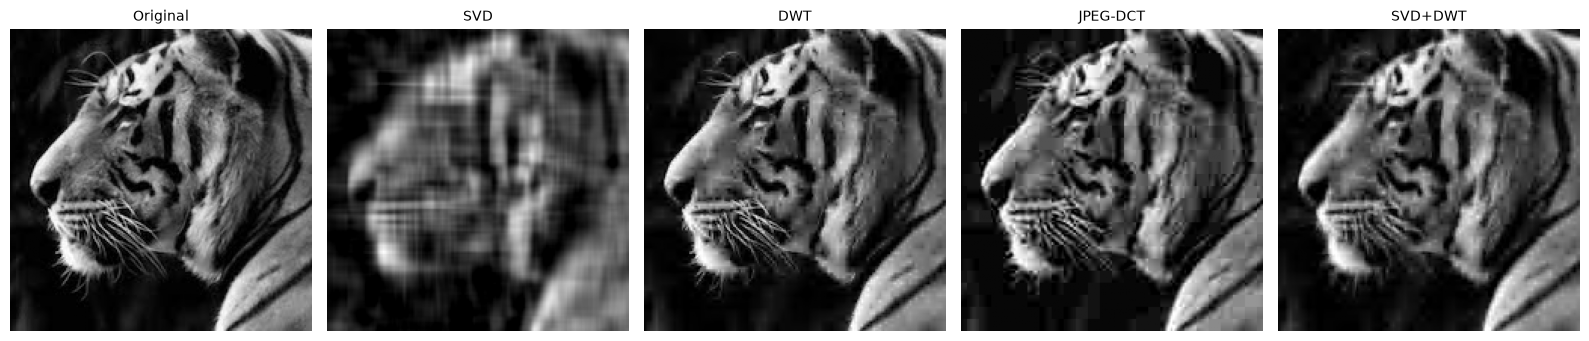

In [33]:
#parametri odabrani tako da svaka metoda ima faktor kompresije ~20x
rec_svd = to_uint8(svd_compression(img, 20))
cf_svd = compression_factor_svd(img.shape, 20)

comp, slices = dwt_compression(img, "db2", "periodization", 5, 0.05)
rec_dwt = to_uint8(dwt_decompression(comp, slices, "db2", "periodization", 5, img.shape))
cf_dwt = compression_factor_dwt(comp)

comp, img_shape = jpeg_compression(img, QTY * 5.5)
rec_dct = to_uint8(jpeg_decompress(comp, QTY * 5.5, img_shape))
cf_dct = compression_factor_dct(comp)

comp, slices = svd_dwt_compression(img, rank_svd=100, compression_level=0.05)
rec_hyb = to_uint8(svd_dwt_decompression(comp, slices, img.shape))
cf_hyb = compression_factor_hybrid(comp)

examples = [("Original", img, None),
            ("SVD (r=20)", rec_svd, cf_svd),
            ("DWT (5% koef.)", rec_dwt, cf_dwt),
            ("JPEG-DCT (Q×5.5)", rec_dct, cf_dct),
            ("SVD+DWT (r=100, 5% koef.)", rec_hyb, cf_hyb)]

fig, axes = plt.subplots(2, 3, figsize=(15, 7.5))
for ax, (name, image, cf) in zip(axes.ravel(), examples):
    ax.imshow(image, cmap="gray", vmin=0, vmax=255)
    if cf is None:
        ax.set_title(name, fontsize=11)
    else:
        ax.set_title(f"{name}\nCF={cf:.1f}x   PSNR={psnr(img, image):.2f} dB   SSIM={ssim(img, image):.3f}",
                     fontsize=10)
    ax.axis("off")
axes.ravel()[-1].axis("off")
plt.tight_layout()
plt.show()

#uvecan isecak (glava tigra) na kome se artefakti najbolje vide
y0, y1, x0, x1 = 120, 320, 140, 340
fig, axes = plt.subplots(1, 5, figsize=(16, 3.8))
for ax, (name, image, _) in zip(axes, examples):
    ax.imshow(image[y0:y1, x0:x1], cmap="gray", vmin=0, vmax=255)
    ax.set_title(name.split(" (")[0], fontsize=10)
    ax.axis("off")
plt.tight_layout()
plt.show()

Na uvećanom isečku vide se karakteristični artefakti svake metode:

* **SVD** - najveći gubitak detalja: pruge i brkovi se razmazuju i javljaju se horizontalno/vertikalno razvučeni „duhovi", jer je slika predstavljena zbirom malog broja matrica ranga 1;
* **DWT** - blago zamućenje sitnih detalja, ali ivice ostaju glatke i nema blokova;
* **JPEG-DCT** - vidljive granice $8 \times 8$ blokova, naročito na glatkim površinama;
* **hibrid SVD+DWT** - vizuelno najbliži DWT-u, uz nešto mekše detalje zbog SVD koraka.

#### Uticaj DWT koraka: poredjenje sa rezultatima iz rada

U radu je hibrid testiran sa rangovima $r = 20, 30, 40, 50$, pri čemu DWT korak zadržava 80% najvećih koeficijenata, pa isti eksperiment ponavljamo na našoj slici: hibrid poredimo sa čistim SVD-om istog ranga.

In [39]:
ranks_paper = [20, 30, 40, 50]

rows = []
for r in ranks_paper:
    rec_s = to_uint8(svd_compression(img, r))
    comp, slices = svd_dwt_compression(img, rank_svd=r, compression_level=0.8)
    rec_h = to_uint8(svd_dwt_decompression(comp, slices, img.shape))
    rows.append({"rang r": r,
                 "PSNR SVD [dB]": round(psnr(img, rec_s), 2),
                 "PSNR hibrid [dB]": round(psnr(img, rec_h), 2),
                 "SSIM SVD": round(ssim(img, rec_s), 4),
                 "SSIM hibrid": round(ssim(img, rec_h), 4)})

pd.DataFrame(rows).set_index("rang r")

,PSNR SVD [dB],PSNR hibrid [dB],SSIM SVD,SSIM hibrid
rang r,,,,
20,20.85,20.85,0.4998,0.4999
30,22.56,22.56,0.5724,0.5723
40,24.02,24.02,0.6290,0.6290
50,25.32,25.32,0.6831,0.6831


Na našoj test slici hibrid pri istom rangu daje identičan rezultat kao čist SVD. Odbačenih 20% najmanjih koeficijenata nosi toliko malo energije da je rekonstrukcija piksel-za-piksel jednaka samoj SVD aproksimaciji. Nalaz iz rada (viši PSNR hibrida pri istom rangu) ovde se, dakle, ne reprodukuje. Suština ipak ostaje: DWT pragovanje se na SVD aproksimaciju nadovezuje praktično „besplatno"  čak i sa znatno oštrijim pragom (20% zadržanih koeficijenata) razlika ostaje ispod 0.02 dB - pa hibrid ostvaruje dodatnu kompresiju bez daljeg pada kvaliteta, što se vidi i na ravnom delu njegove *rate-distortion* krive.

#### Zbirna tabela rezultata

Sve izmerene vrednosti na jednom mestu (ista test slika, `data/tiger.jpg`):

## Zakljucak